# R4 - Análisis cuantitativo del procedimiento ROI y fallback

Este notebook cierra la etapa R4 caracterizando de forma reproducible cómo una máscara producida por el U-Net baseline congelado se transforma en una región de interés (ROI) que posteriormente podrá consumir R5.

El análisis se realiza únicamente sobre **validation**, utilizando el checkpoint de `threshold = 0.5`. No se modifica la arquitectura, el entrenamiento, la loss ni el umbral del segmentador.

## 1. Configuración del entorno

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import torch
import cv2
import matplotlib.pyplot as plt
from PIL import Image

PROJECT_ROOT = Path("../..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

PROJECT_ROOT: /home/jvillanueva/projects/ovarian-tumor-ultrasound-classification
Device: cuda
GPU: NVIDIA GeForce RTX 3080


## 2. Rutas y configuración del experimento

In [2]:
DATASET_DIR = ( PROJECT_ROOT / "data" / "processed" / "MMOTU_OTU_2D_experimental" )
MODEL_PATH = ( PROJECT_ROOT / "models" / "segmentation" / "unet_baseline_best.pth" )
RESULT_DIR = ( PROJECT_ROOT / "results" / "segmentation" / "unet_baseline" )

VAL_DIR = RESULT_DIR / "validation"
VAL_METRICS_PATH = VAL_DIR / "validation_per_image_metrics.csv"

PREDICTED_MASKS_DIR = VAL_DIR / "predicted_masks"
FIGURES_DIR = VAL_DIR / "figures"

ROI_PER_IMAGE_PATH = VAL_DIR / "roi_analysis_per_image.csv"
ROI_MARGIN_COVERAGE_PATH = VAL_DIR / "roi_margin_coverage.csv"

PREDICTED_MASKS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

VAL_IMAGES_DIR = DATASET_DIR / "validation" / "images"
VAL_MASKS_DIR = DATASET_DIR / "validation" / "masks"

print("Checkpoint:", MODEL_PATH.exists(), MODEL_PATH)
print("Validation imágenes:", VAL_IMAGES_DIR.exists(), VAL_IMAGES_DIR)
print("Validation máscaras:", VAL_MASKS_DIR.exists(), VAL_MASKS_DIR)
print("Métricas por imagen:", VAL_METRICS_PATH.exists(), VAL_METRICS_PATH)
print("Máscaras predichas (destino):", PREDICTED_MASKS_DIR)

Checkpoint: True /home/jvillanueva/projects/ovarian-tumor-ultrasound-classification/models/segmentation/unet_baseline_best.pth
Validation imágenes: True /home/jvillanueva/projects/ovarian-tumor-ultrasound-classification/data/processed/MMOTU_OTU_2D_experimental/validation/images
Validation máscaras: True /home/jvillanueva/projects/ovarian-tumor-ultrasound-classification/data/processed/MMOTU_OTU_2D_experimental/validation/masks
Métricas por imagen: True /home/jvillanueva/projects/ovarian-tumor-ultrasound-classification/results/segmentation/unet_baseline/validation/validation_per_image_metrics.csv
Máscaras predichas (destino): /home/jvillanueva/projects/ovarian-tumor-ultrasound-classification/results/segmentation/unet_baseline/validation/predicted_masks


## 3. Carga del U-Net baseline congelado

In [3]:
from src.segmentation.unet import UNet
from src.segmentation.dataset import OvarianTumorSegmentationDataset

checkpoint = torch.load( MODEL_PATH, map_location=device, )

IMAGE_SIZE = tuple(checkpoint["image_size"])
THRESHOLD = float(checkpoint.get("threshold", 0.5))

print("Época guardada:", checkpoint["epoch"])
print("Validation Dice:", checkpoint["val_dice"])
print("Image size U-Net:", IMAGE_SIZE)
print("Threshold:", THRESHOLD)

model = UNet( in_channels=3, out_channels=1, ).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("\nModelo cargado correctamente.")

/tmp/ipykernel_12794/1221786208.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load( MODEL_PATH, map_location=device, )


Época guardada: 45
Validation Dice: 0.714591618180275
Image size U-Net: (256, 256)
Threshold: 0.5

Modelo cargado correctamente.


## 4. Generación y persistencia de máscaras predichas de validation

Para evitar re-ejecutar inferencia en cada análisis posterior, se persiste la salida binaria del U-Net congelado (threshold = 0.5) en la resolución nativa del modelo (256×256).

In [4]:
from src.segmentation.roi import predict_binary_mask


def persist_validation_predictions(
    images_dir,
    output_dir,
    model,
    device,
    image_size,
    threshold,
    overwrite=False,
):
    """
    Genera y guarda las máscaras binarias predichas por el U-Net congelado para la partición 
    de validation. Las máscaras se persisten en la resolución nativa del modelo (image_size),
    como PNG uint8 con valores {0, 255}.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    image_paths = sorted( Path(images_dir).iterdir(), key=lambda p: int(p.stem), )
    records = []

    for image_path in image_paths:
        image_id = image_path.stem
        output_path = output_dir / f"{image_id}_pred.png"

        if output_path.exists() and not overwrite:
            records.append({"image_id": image_id, "status": "skipped"})
            continue

        with Image.open(image_path) as image:
            image = image.convert("RGB")
            binary_mask, _ = predict_binary_mask(
                model=model,
                image=image,
                device=device,
                image_size=image_size,
                threshold=threshold,
            )

        png = (binary_mask.astype(np.uint8) * 255)
        Image.fromarray(png, mode="L").save(output_path)

        records.append({"image_id": image_id, "status": "written"})

    return pd.DataFrame(records)


persist_log = persist_validation_predictions(
    images_dir=VAL_IMAGES_DIR,
    output_dir=PREDICTED_MASKS_DIR,
    model=model,
    device=device,
    image_size=IMAGE_SIZE,
    threshold=THRESHOLD,
    overwrite=False,
)

print("Máscaras generadas:", (persist_log["status"] == "written").sum())
print("Máscaras ya existentes:", (persist_log["status"] == "skipped").sum())
print("Total validation:", len(persist_log))

Máscaras generadas: 0
Máscaras ya existentes: 200
Total validation: 200


## 5. Funciones de carga y análisis geométrico

El análisis geométrico se realiza en la **resolución original** de cada imagen, porque el crop que utilizará posteriormente operará sobre la imagen original. El flujo es:

```
salida U-Net (256×256) → resize nearest-neighbor → resolución original → connected components → bbox → margen → crop ROI
```

In [5]:
from src.segmentation.roi import (
    resize_mask_to_image,
    keep_largest_component,
    mask_to_bbox,
    expand_bbox,
)


def load_image_rgb(image_path):
    with Image.open(image_path) as image:
        return image.convert("RGB")


def load_gt_mask_original(mask_path):
    """
    Carga una máscara GT a su resolución original como uint8 binaria {0,1}.
    """
    with Image.open(mask_path) as mask:
        mask = mask.convert("L")
        array = np.asarray(mask, dtype=np.uint8)

    return (array > 0).astype(np.uint8)


def load_predicted_mask(pred_path, image_size):
    """
    Carga una máscara predicha persistida (256x256) y la redimensiona a la resolución original 
    de la imagen mediante nearest-neighbor.
    """
    with Image.open(pred_path) as mask:
        mask = mask.convert("L")
        array = np.asarray(mask, dtype=np.uint8)

    binary = (array > 127).astype(np.uint8)

    return resize_mask_to_image(binary, image_size=image_size)


def analyze_connected_components(binary_mask):
    """
    Describe las componentes conexas de una máscara binaria.

    Devuelve un diccionario con:
    - n_components: número de componentes (sin contar fondo).
    - total_area: suma de píxeles positivos.
    - largest_component_area: área de la componente mayor.
    - largest_component_fraction_of_total: fracción del área total
      que corresponde a la componente mayor.
    - image_area: alto x ancho de la máscara.
    - largest_component_area_fraction: largest_component_area / image_area.
    """
    mask = (binary_mask > 0).astype(np.uint8)
    image_area = int(mask.shape[0] * mask.shape[1])
    total_area = int(mask.sum())

    if total_area == 0:
        return {
            "n_components": 0,
            "total_area": 0,
            "largest_component_area": 0,
            "largest_component_fraction_of_total": 0.0,
            "image_area": image_area,
            "largest_component_area_fraction": 0.0,
        }

    n_labels, _, stats, _ = cv2.connectedComponentsWithStats( mask, connectivity=8, )
    component_areas = stats[1:, cv2.CC_STAT_AREA]
    largest_area = int(component_areas.max()) if component_areas.size > 0 else 0

    return {
        "n_components": int(n_labels - 1),
        "total_area": total_area,
        "largest_component_area": largest_area,
        "largest_component_fraction_of_total": (
            largest_area / total_area if total_area > 0 else 0.0
        ),
        "image_area": image_area,
        "largest_component_area_fraction": (
            largest_area / image_area if image_area > 0 else 0.0
        ),
    }


def bbox_iou(bbox_a, bbox_b):
    """
    IoU entre dos bounding boxes (left, top, right, bottom), con right y bottom exclusivos. 
    Devuelve 0 si alguno es None.
    """
    if bbox_a is None or bbox_b is None:
        return 0.0

    ax0, ay0, ax1, ay1 = bbox_a
    bx0, by0, bx1, by1 = bbox_b

    ix0 = max(ax0, bx0)
    iy0 = max(ay0, by0)
    ix1 = min(ax1, bx1)
    iy1 = min(ay1, by1)

    inter = max(0, ix1 - ix0) * max(0, iy1 - iy0)

    area_a = max(0, ax1 - ax0) * max(0, ay1 - ay0)
    area_b = max(0, bx1 - bx0) * max(0, by1 - by0)
    union = area_a + area_b - inter

    if union <= 0:
        return 0.0

    return inter / union

## 6. Análisis de componentes conexas (GT y predicción)

Se cuantifica, para cada imagen de validation y a resolución original:

- número de componentes conexas en la máscara GT y en la predicha,
- fracción del área GT total correspondiente a la componente principal,
- fracción del área de la imagen que ocupan GT y predicción,
- `largest_component_area_fraction` para la predicción (variable de referencia para discutir el criterio de máscara degenerada).

No se aplica `keep_largest_component` sobre la GT en este cálculo: lo que se busca es describir la distribución real de GT multicomponente antes de decidir cómo tratarla.

In [6]:
def compute_per_image_roi_table( val_images_dir, val_masks_dir, predicted_masks_dir, image_size, ):
    """
    Construye la tabla por imagen con métricas de componentes conexas, áreas y bbox IoU, operando 
    siempre a resolución original.
    """
    image_paths = sorted( Path(val_images_dir).iterdir(), key=lambda p: int(p.stem), )
    records = []

    for image_path in image_paths:
        image_id = image_path.stem
        gt_path = Path(val_masks_dir) / f"{image_id}_binary.PNG"
        pred_path = Path(predicted_masks_dir) / f"{image_id}_pred.png"

        with Image.open(image_path) as image:
            image_size_original = image.size

        gt_mask = load_gt_mask_original(gt_path)
        pred_mask = load_predicted_mask(pred_path, image_size=image_size_original)

        gt_cc = analyze_connected_components(gt_mask)
        pred_cc = analyze_connected_components(pred_mask)

        pred_largest = keep_largest_component(pred_mask)

        gt_bbox = mask_to_bbox(gt_mask)
        pred_bbox = mask_to_bbox(pred_largest)

        records.append(
            {
                "image_id": image_id,
                "image_width": image_size_original[0],
                "image_height": image_size_original[1],
                "gt_num_components": gt_cc["n_components"],
                "gt_area_fraction": gt_cc["total_area"] / gt_cc["image_area"],
                "gt_largest_component_fraction": gt_cc[
                    "largest_component_fraction_of_total"
                ],
                "pred_num_components": pred_cc["n_components"],
                "pred_area_fraction": (
                    pred_cc["total_area"] / pred_cc["image_area"]
                ),
                "largest_component_area_fraction": pred_cc[
                    "largest_component_area_fraction"
                ],
                "pred_empty": pred_cc["n_components"] == 0,
                "bbox_iou": bbox_iou(gt_bbox, pred_bbox),
            }
        )

    return pd.DataFrame(records)


roi_per_image_df = compute_per_image_roi_table(
    val_images_dir=VAL_IMAGES_DIR,
    val_masks_dir=VAL_MASKS_DIR,
    predicted_masks_dir=PREDICTED_MASKS_DIR,
    image_size=IMAGE_SIZE,
)

val_metrics_df = pd.read_csv(VAL_METRICS_PATH)
val_metrics_df["image_id"] = val_metrics_df["image_id"].astype(str)

roi_per_image_df = roi_per_image_df.merge(
    val_metrics_df[["image_id", "dice", "iou"]],
    on="image_id",
    how="left",
)

print("Imágenes analizadas:", len(roi_per_image_df))
display(roi_per_image_df.head())

Imágenes analizadas: 200


,image_id,image_width,image_height,gt_num_components,gt_area_fraction,gt_largest_component_fraction,pred_num_components,pred_area_fraction,largest_component_area_fraction,pred_empty,bbox_iou,dice,iou
0,6,958,534,1,0.142885,1.0,1,0.138549,0.138549,False,0.944748,0.974957,0.951137
1,11,480,530,1,0.274953,1.0,1,0.269914,0.269914,False,0.962520,0.981163,0.963022
2,13,958,530,1,0.156560,1.0,2,0.164976,0.159294,False,0.983834,0.958495,0.920298
3,17,959,536,1,0.081469,1.0,1,0.086282,0.086282,False,0.855168,0.947187,0.899672
4,19,958,534,1,0.170001,1.0,1,0.173682,0.173682,False,0.840426,0.940576,0.887818


In [7]:
# Ground True
gt_components_distribution = (
    roi_per_image_df["gt_num_components"]
    .value_counts()
    .sort_index()
    .rename("n_imagenes")
    .to_frame()
)
gt_components_distribution["porcentaje"] = ( 100.0 * gt_components_distribution["n_imagenes"] / len(roi_per_image_df) )

# Predicted
pred_components_distribution = (
    roi_per_image_df["pred_num_components"]
    .value_counts()
    .sort_index()
    .rename("n_imagenes")
    .to_frame()
)
pred_components_distribution["porcentaje"] = ( 100.0 * pred_components_distribution["n_imagenes"] / len(roi_per_image_df) )

print("GT - número de componentes conexas")
display(gt_components_distribution)

print("Predicción - número de componentes conexas")
display(pred_components_distribution)

gt_multicomponent = roi_per_image_df[roi_per_image_df["gt_num_components"] >= 2]
if len(gt_multicomponent) > 0:
    print( "GT multicomponente - fracción del área total correspondiente a la componente principal:" )
    display( gt_multicomponent["gt_largest_component_fraction"].describe() )
else:
    print("No existen máscaras GT con más de una componente conexa.")

GT - número de componentes conexas


,n_imagenes,porcentaje
gt_num_components,,
1,197,98.5
2,3,1.5


Predicción - número de componentes conexas


,n_imagenes,porcentaje
pred_num_components,,
1,106,53.0
2,36,18.0
3,24,12.0
4,10,5.0
5,12,6.0
6,3,1.5
7,4,2.0
8,1,0.5
10,1,0.5


GT multicomponente - fracción del área total correspondiente a la componente principal:


count    3.000000
mean     0.736294
std      0.027904
min      0.705385
25%      0.724626
50%      0.743868
75%      0.751748
max      0.759629
Name: gt_largest_component_fraction, dtype: float64

## 7. Áreas predichas y detección potencial de máscaras degeneradas

Se analiza la distribución de `largest_component_area_fraction` (área de la mayor componente predicha, normalizada por el área de la imagen original) y su relación con `gt_area_fraction`, `pred_area_fraction` y Dice. El objetivo es verificar si existe una separación empírica clara entre:

- predicciones vacías o degeneradas (candidatas al fallback a imagen completa), y
- predicciones con lesión plausible.

In [8]:
print("largest_component_area_fraction (predicción):")
display(roi_per_image_df["largest_component_area_fraction"].describe())

print("gt_area_fraction:")
display(roi_per_image_df["gt_area_fraction"].describe())

print("pred_area_fraction:")
display(roi_per_image_df["pred_area_fraction"].describe())

empty_count = int(roi_per_image_df["pred_empty"].sum())
print(f"\nMáscaras predichas vacías: {empty_count} / {len(roi_per_image_df)}")

largest_component_area_fraction (predicción):


count    200.000000
mean       0.130725
std        0.099814
min        0.000163
25%        0.055646
50%        0.103094
75%        0.182523
max        0.419579
Name: largest_component_area_fraction, dtype: float64

gt_area_fraction:


count    200.000000
mean       0.144581
std        0.113903
min        0.005415
25%        0.054483
50%        0.108286
75%        0.202808
max        0.522245
Name: gt_area_fraction, dtype: float64

pred_area_fraction:


count    200.000000
mean       0.135922
std        0.097666
min        0.000163
25%        0.064623
50%        0.110894
75%        0.183078
max        0.419579
Name: pred_area_fraction, dtype: float64


Máscaras predichas vacías: 0 / 200


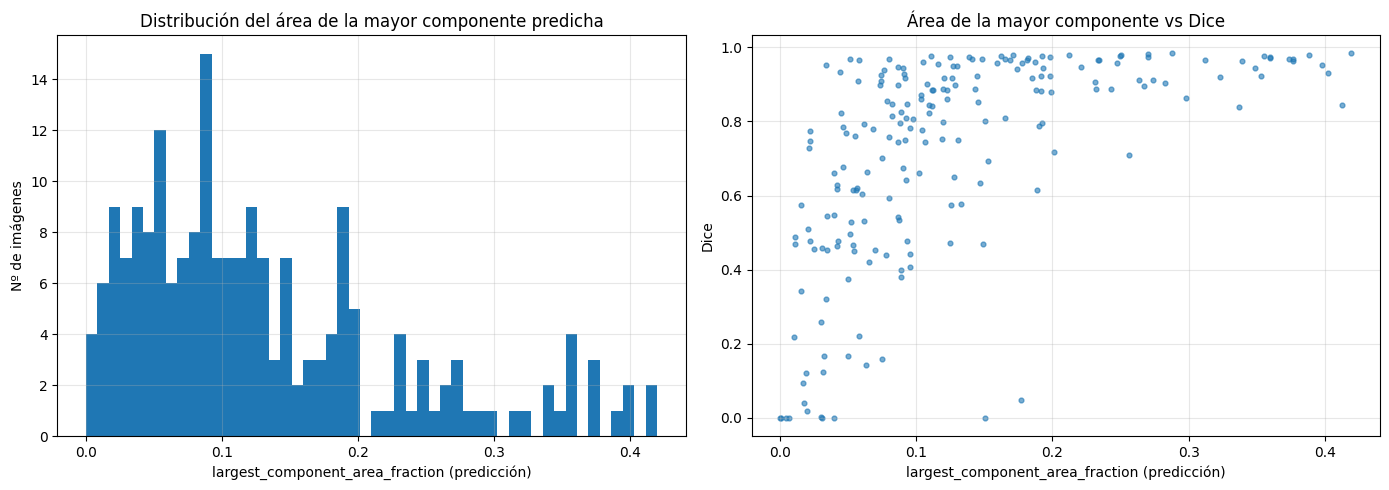

In [9]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

axes[0].hist( roi_per_image_df["largest_component_area_fraction"], bins=50, )
axes[0].set_xlabel("largest_component_area_fraction (predicción)")
axes[0].set_ylabel("Nº de imágenes")
axes[0].set_title("Distribución del área de la mayor componente predicha")
axes[0].grid(alpha=0.3)

axes[1].scatter(
    roi_per_image_df["largest_component_area_fraction"],
    roi_per_image_df["dice"],
    s=12,
    alpha=0.6,
)
axes[1].set_xlabel("largest_component_area_fraction (predicción)")
axes[1].set_ylabel("Dice")
axes[1].set_title("Área de la mayor componente vs Dice")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "largest_component_area_fraction_distribution.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [10]:
small_pred_df = (
    roi_per_image_df
    .sort_values("largest_component_area_fraction")
    .head(20)[
        [
            "image_id",
            "dice",
            "gt_area_fraction",
            "pred_area_fraction",
            "largest_component_area_fraction",
            "pred_num_components",
            "pred_empty",
        ]
    ]
    .reset_index(drop=True)
)

print("20 predicciones con menor largest_component_area_fraction:")
display(small_pred_df)

20 predicciones con menor largest_component_area_fraction:


,image_id,dice,gt_area_fraction,pred_area_fraction,largest_component_area_fraction,pred_num_components,pred_empty
0,775,5.380104e-12,0.283418,0.000163,0.000163,1,False
1,869,1.748252e-10,0.008290,0.000368,0.000326,2,False
2,599,1.061571e-10,0.009934,0.004479,0.004149,3,False
3,347,4.450378e-11,0.025797,0.008520,0.006140,3,False
4,1436,2.188139e-01,0.026988,0.017713,0.009930,6,False
5,807,4.880709e-01,0.008509,0.013864,0.010721,5,False
6,982,4.698372e-01,0.036428,0.011256,0.011214,2,False
7,334,5.749928e-01,0.025098,0.027356,0.015286,12,False
8,755,3.420603e-01,0.129870,0.031169,0.015640,3,False
9,231,9.355162e-02,0.021978,0.023751,0.016555,3,False


## 8. Evaluación geométrica de márgenes de bounding box

Para cada imagen con máscara predicha no vacía se construye el bbox a partir de la componente principal predicha y se expande con `margin_ratio ∈ {0.00, 0.05, 0.10, 0.20}`. 

Para cada margen, se calcula la cobertura de lesión GT:
```
lesion_coverage = (GT lesion pixels inside ROI) / (total GT lesion pixels)
```

y el tamaño relativo del ROI:
```
roi_area_fraction = roi_area / image_area`)
```

Se excluyen de este cálculo las imágenes donde la predicción es vacía (allí el fallback a imagen completa daría cobertura 1.0 trivialmente y distorsionaría la comparación geométrica). También, se reportan las imágenes donde la GT es vacía, para dejar constancia.

In [12]:
MARGIN_CANDIDATES = [0.00, 0.05, 0.10, 0.20]

def compute_margin_coverage(
    val_images_dir,
    val_masks_dir,
    predicted_masks_dir,
    image_size,
    margins,
):
    """
    Para cada imagen con predicción no vacía y GT no vacía, calcula la cobertura de lesión GT y 
    el tamaño relativo de la ROI para cada margen. Devuelve una tabla larga con columnas 
    (image_id, margin, lesion_coverage, roi_area_fraction, roi_width, roi_height).
    """
    image_paths = sorted( Path(val_images_dir).iterdir(), key=lambda p: int(p.stem), )
    records = []

    for image_path in image_paths:
        image_id = image_path.stem
        gt_path = Path(val_masks_dir) / f"{image_id}_binary.PNG"
        pred_path = Path(predicted_masks_dir) / f"{image_id}_pred.png"

        with Image.open(image_path) as image:
            image_width, image_height = image.size

        gt_mask = load_gt_mask_original(gt_path)
        pred_mask = load_predicted_mask( pred_path, image_size=(image_width, image_height), )

        gt_total = int(gt_mask.sum())
        if gt_total == 0:
            continue

        pred_largest = keep_largest_component(pred_mask)
        pred_bbox = mask_to_bbox(pred_largest)

        if pred_bbox is None:
            continue

        image_area = image_width * image_height

        for margin in margins:
            left, top, right, bottom = expand_bbox(
                bbox=pred_bbox,
                image_size=(image_width, image_height),
                margin_ratio=margin,
            )

            roi_width = right - left
            roi_height = bottom - top
            roi_area = roi_width * roi_height

            gt_inside = int(gt_mask[top:bottom, left:right].sum())
            lesion_coverage = gt_inside / gt_total

            records.append(
                {
                    "image_id": image_id,
                    "margin": margin,
                    "lesion_coverage": lesion_coverage,
                    "roi_width": roi_width,
                    "roi_height": roi_height,
                    "roi_area_fraction": (
                        roi_area / image_area if image_area > 0 else 0.0
                    ),
                }
            )

    return pd.DataFrame(records)


margin_long_df = compute_margin_coverage(
    val_images_dir=VAL_IMAGES_DIR,
    val_masks_dir=VAL_MASKS_DIR,
    predicted_masks_dir=PREDICTED_MASKS_DIR,
    image_size=IMAGE_SIZE,
    margins=MARGIN_CANDIDATES,
)

n_cases_analyzed = margin_long_df["image_id"].nunique()
print("Imágenes consideradas en el análisis de márgenes:", n_cases_analyzed)

Imágenes consideradas en el análisis de márgenes: 200


In [13]:
def summarize_margin_coverage(margin_long_df):
    rows = []

    for margin, group in margin_long_df.groupby("margin"):
        coverage = group["lesion_coverage"]
        roi_frac = group["roi_area_fraction"]

        rows.append(
            {
                "margin": margin,
                "n": len(group),
                "coverage_mean": coverage.mean(),
                "coverage_median": coverage.median(),
                "pct_coverage_ge_0_90": 100.0 * (coverage >= 0.90).mean(),
                "pct_coverage_ge_0_95": 100.0 * (coverage >= 0.95).mean(),
                "pct_coverage_ge_0_99": 100.0 * (coverage >= 0.99).mean(),
                "roi_area_fraction_mean": roi_frac.mean(),
                "roi_area_fraction_median": roi_frac.median(),
            }
        )

    return pd.DataFrame(rows).sort_values("margin").reset_index(drop=True)


margin_summary_df = summarize_margin_coverage(margin_long_df)

display(margin_summary_df)

,margin,n,coverage_mean,coverage_median,pct_coverage_ge_0_90,pct_coverage_ge_0_95,pct_coverage_ge_0_99,roi_area_fraction_mean,roi_area_fraction_median
0,0.00,200,0.815686,0.968908,66.0,56.0,40.5,0.188341,0.151226
1,0.05,200,0.845277,0.998703,73.0,66.5,55.0,0.227328,0.182806
2,0.10,200,0.864355,1.000000,77.0,71.0,65.0,0.267615,0.218345
3,0.20,200,0.891222,1.000000,81.5,78.0,74.0,0.348455,0.294424


## 9. Casos representativos

Se visualizan los tres casos usados: peor, mediano y mejor por Dice en validation, mostrando para cada uno la imagen original, la máscara GT, la predicción binaria y los recortes ROI para los márgenes evaluados.

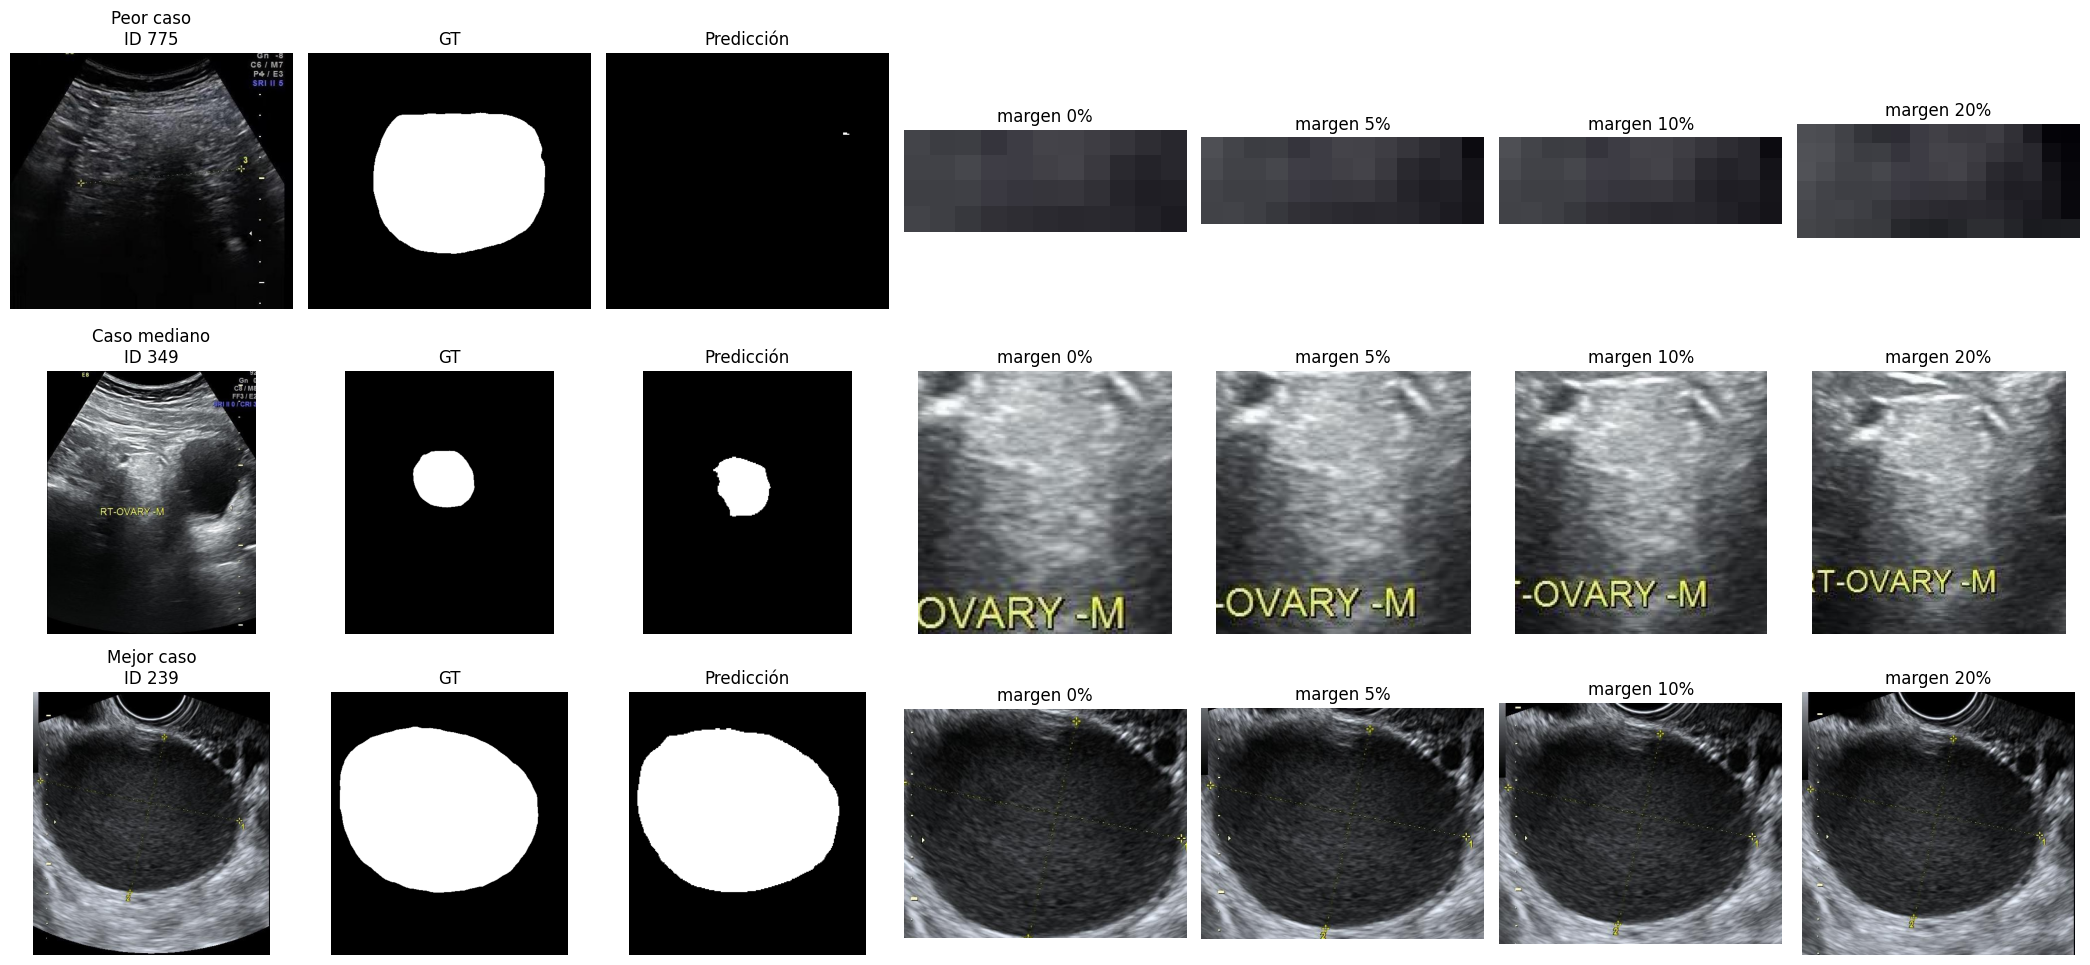

In [14]:
sorted_by_dice = roi_per_image_df.sort_values("dice").reset_index(drop=True)

case_ids = {
    "Peor caso": str(sorted_by_dice.iloc[0]["image_id"]),
    "Caso mediano": str(sorted_by_dice.iloc[len(sorted_by_dice) // 2]["image_id"]),
    "Mejor caso": str(sorted_by_dice.iloc[-1]["image_id"]),
}

n_rows = len(case_ids)
n_cols = 3 + len(MARGIN_CANDIDATES)

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(3.0 * n_cols, 3.2 * n_rows),
)

for row, (case_name, image_id) in enumerate(case_ids.items()):
    image_path = VAL_IMAGES_DIR / f"{image_id}.JPG"
    gt_path = VAL_MASKS_DIR / f"{image_id}_binary.PNG"
    pred_path = PREDICTED_MASKS_DIR / f"{image_id}_pred.png"

    image = load_image_rgb(image_path)
    gt_mask = load_gt_mask_original(gt_path)
    pred_mask = load_predicted_mask(pred_path, image_size=image.size)
    pred_largest = keep_largest_component(pred_mask)
    pred_bbox = mask_to_bbox(pred_largest)

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(f"{case_name}\nID {image_id}")

    axes[row, 1].imshow(gt_mask, cmap="gray")
    axes[row, 1].set_title("GT")

    axes[row, 2].imshow(pred_mask, cmap="gray")
    axes[row, 2].set_title("Predicción")

    for col_offset, margin in enumerate(MARGIN_CANDIDATES):
        col = 3 + col_offset

        if pred_bbox is None:
            axes[row, col].imshow(image)
            axes[row, col].set_title(f"margen {int(margin * 100)}%\n(fallback)")
        else:
            bbox = expand_bbox(
                bbox=pred_bbox,
                image_size=image.size,
                margin_ratio=margin,
            )
            crop = image.crop(bbox)
            axes[row, col].imshow(crop)
            axes[row, col].set_title(f"margen {int(margin * 100)}%")

    for col in range(n_cols):
        axes[row, col].axis("off")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "representative_roi_margins_validation.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 10. Persistencia de resultados

In [15]:
roi_per_image_df.to_csv(
    ROI_PER_IMAGE_PATH,
    index=False,
    encoding="utf-8-sig",
)

margin_summary_df.to_csv(
    ROI_MARGIN_COVERAGE_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("Guardado:", ROI_PER_IMAGE_PATH)
print("Guardado:", ROI_MARGIN_COVERAGE_PATH)

Guardado: /home/jvillanueva/projects/ovarian-tumor-ultrasound-classification/results/segmentation/unet_baseline/validation/roi_analysis_per_image.csv
Guardado: /home/jvillanueva/projects/ovarian-tumor-ultrasound-classification/results/segmentation/unet_baseline/validation/roi_margin_coverage.csv


## 11. Decisiones aprobadas

A partir de los resultados obtenidos en este análisis se aprobaron las siguientes decisiones para el procedimiento ROI:

| Parámetro | Valor | Justificación |
|---|---|---|
| `keep_largest_component` (predicción) | `True` | Solo el 53 % de las predicciones tiene una única componente; el ruido multi-componente se descarta conservando la mayor. |
| `keep_largest_component` (GT) | `False` | El 98.5 % de las GT tiene una componente. Las 3 GT bicomponente tienen componentes secundarias relevantes (~24–30 % del área GT), por lo que descartarlas perdería información de referencia. |
| `min_component_area_fraction` | `0.001` | Los 2 únicos casos con fracción < 0.001 (IDs 775 y 869) tienen Dice ≈ 0 y producen ROIs degeneradas. Existe un gap de 12× hasta el siguiente caso (0.0003 → 0.004). |
| Fallback a imagen completa | máscara vacía **o** `largest_component_area_fraction < 0.001` | Unifica el criterio anterior (solo máscara vacía) con el nuevo criterio de componente degenerada. |
| `margin_ratio` | `0.10` | Con 10 % de margen la mediana de cobertura GT alcanza 1.0, con 77 % de casos ≥ 90 % y 65 % ≥ 99 %. El incremento a 20 % añade +8 pp de `roi_area_fraction` pero solo +4.5 pp en ≥ 90 %. |
